# Urban Pulse — Modeling: XGBoost

Notebook ini melatih model klasifikasi slum/non-slum menggunakan
**XGBoost** (selaras dengan model final di README proyek), melakukan
**threshold tuning** untuk prioritas recall, menghasilkan **local SHAP**
untuk menjelaskan prediksi per area, dan **mengekspor artefak** (`.joblib`
+ `model_metadata.json`) yang siap dipakai oleh `model_service.py`.

**Skema evaluasi:**
1. **Leave-One-City-Out (LOCO)** — metrik evaluasi UTAMA. Untuk setiap
   kota, model dilatih pakai 3 kota lain lalu diuji pada kota yang
   di-hold-out. Ini mensimulasikan kondisi nyata: prediksi pada kota baru
   yang belum pernah dilihat model.
2. **Random stratified split (80/20)** — sanity check sekunder.

**Threshold tuning:** dipilih dengan target **recall ≥ 0.80** pada kelas
slum, bukan F1 atau akurasi — karena pada kasus screening permukiman
kumuh, melewatkan area kumuh nyata (false negative) jauh lebih merugikan
daripada false alarm (false positive) yang masih bisa disaring lewat
verifikasi lapangan lanjutan.

**Interpretability:** SHAP (TreeExplainer) dipakai dalam dua bentuk:
- **Global** — rata-rata kontribusi fitur di seluruh dataset, untuk
  validasi bahwa model belajar pola yang masuk akal secara domain.
- **Local** — kontribusi fitur untuk SATU area spesifik, sesuai kebutuhan
  fitur "Key Factors" pada README (`/explain` endpoint).

**Input**: `data/processed/features_buildings_clean.csv` +
`data/processed/feature_columns.csv` (hasil notebook preprocessing.ipynb)

**Output**: `models/slum_xgb_pipeline.joblib` + `models/model_metadata.json`

## Referensi akademik

- **XGBoost**: Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree
  boosting system. In *Proceedings of the 22nd ACM SIGKDD International
  Conference on Knowledge Discovery and Data Mining* (pp. 785–794).
  https://doi.org/10.1145/2939672.2939785 (arXiv:1603.02754)
- **Random Forest/XGBoost untuk slum mapping di Indonesia**: Leonita, G.,
  Kuffer, M., Sliuzas, R., & Persello, C. (2018). Machine learning-based
  slum mapping in support of slum upgrading programs: The case of Bandung
  City, Indonesia. *Remote Sensing*, 10(10), 1522.
  https://doi.org/10.3390/rs10101522
- **SHAP (SHapley Additive exPlanations)**: Lundberg, S. M., & Lee, S. I.
  (2017). A unified approach to interpreting model predictions. In
  *Advances in Neural Information Processing Systems 30* (NeurIPS 2017)
  (pp. 4765–4774). arXiv:1705.07874
- **Penanganan class imbalance lewat pembobotan kelas**: King, G., &
  Zeng, L. (2001). Logistic regression in rare events data. *Political
  Analysis*, 9(2), 137–163; López, V., Fernández, A., García, S., Palade,
  V., & Herrera, F. (2012). An insight into classification with
  imbalanced data. *Information Sciences*, 250, 113–141.
- **Cost-sensitive thresholding** (dasar pemilihan recall sebagai target
  utama, bukan F1/akurasi): López et al. (2012), op. cit.
- **Leave-One-Region-Out / spatial cross-validation**: Roberts, D. R.,
  Bahn, V., Ciuti, S., et al. (2017). Cross-validation strategies for
  data with temporal, spatial, hierarchical, or phylogenetic structure.
  *Ecography*, 40(8), 913–929.

In [1]:
from __future__ import annotations

import json
from datetime import date
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
)
from xgboost import XGBClassifier
import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
RANDOM_STATE = 42

## 0. Konfigurasi

In [2]:
PROCESSED_DIR = Path("data/processed")
DATA_PATH = PROCESSED_DIR / "features_buildings_clean.csv"
FEATURE_COLS_PATH = PROCESSED_DIR / "feature_columns.csv"

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "slum_xgb_pipeline.joblib"
METADATA_PATH = MODELS_DIR / "model_metadata.json"

TARGET_COL = "slum"
CITY_COL = "city"
TEST_SIZE = 0.2
TARGET_RECALL = 0.80  # target minimum recall kelas slum untuk threshold tuning

## 1. Load data

Memakai dataset bersih hasil `preprocessing.ipynb` — 41 fitur yang sudah
dipastikan bebas dari kolom leakage (`slum_frac`, `kumuh_lvl` sudah
dikeluarkan oleh tahap preprocessing).

In [3]:
df = pd.read_csv(DATA_PATH)
feature_cols = pd.read_csv(FEATURE_COLS_PATH)["feature_name"].tolist()

print(f"Dataset: {df.shape}")
print(f"Jumlah fitur model: {len(feature_cols)}")
print(f"Distribusi kelas: slum={int(df[TARGET_COL].sum())} "
      f"({df[TARGET_COL].mean()*100:.1f}%) / "
      f"non-slum={int((df[TARGET_COL]==0).sum())}")

df[[CITY_COL, TARGET_COL]].groupby(CITY_COL)[TARGET_COL].agg(["count", "sum", "mean"]) \
    .rename(columns={"count": "total", "sum": "slum", "mean": "pct_slum"})

Dataset: (830, 49)
Jumlah fitur model: 41
Distribusi kelas: slum=118 (14.2%) / non-slum=712


,total,slum,pct_slum
city,,,
ambon,50,15,0.300000
dki,261,62,0.237548
kebumen,460,27,0.058696
samarinda,59,14,0.237288


## 2. Definisi model

`scale_pos_weight` (rasio non-slum/slum) dipakai untuk menangani class
imbalance dengan pembobotan kelas (cost-sensitive learning) — lihat King
& Zeng (2001) dan López et al. (2012) pada daftar referensi. Parameter
regularisasi dijaga konservatif (`max_depth` kecil, `subsample` < 1)
karena ukuran dataset relatif kecil (830 baris), untuk menghindari
overfitting.

In [4]:
def make_xgb(scale_pos_weight=1.0, random_state=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=random_state,
        n_jobs=-1,
    )

## 3. Evaluasi LOCO (Leave-One-City-Out) — metrik utama

Untuk setiap kota: train pakai 3 kota lain, test pada kota yang
di-hold-out, dengan **threshold default 0.5** dulu (threshold tuning
yang sesungguhnya ada di Bagian 5, setelah pola umum performa terlihat).

In [5]:
def run_loco_evaluation(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    cities = sorted(df[CITY_COL].unique())
    rows = []

    for city in cities:
        # Baris kota ini jadi TEST, sisanya (3 kota lain) jadi TRAIN
        train_mask = df[CITY_COL] != city
        test_mask = df[CITY_COL] == city

        X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, TARGET_COL]
        X_test, y_test = df.loc[test_mask, feature_cols], df.loc[test_mask, TARGET_COL]

        # Hitung ulang rasio class imbalance KHUSUS untuk data train fold ini
        # (rasio bisa beda-beda tiap fold karena 3 kota yang dipakai train berubah-ubah)
        pos, neg = y_train.sum(), len(y_train) - y_train.sum()
        spw = neg / max(pos, 1)

        model = make_xgb(scale_pos_weight=spw)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)                  # prediksi 0/1 pakai threshold default 0.5
        y_proba = model.predict_proba(X_test)[:, 1]      # probabilitas mentah kelas slum (kolom index 1)

        try:
            auc = roc_auc_score(y_test, y_proba)
        except ValueError:
            # ROC-AUC butuh kedua kelas (0 dan 1) ada di y_test; kalau test set
            # cuma berisi 1 kelas saja, hitungannya tidak valid -> isi NaN saja
            auc = np.nan

        rows.append({
            "held_out_city": city,
            "n_test": len(y_test),
            "n_slum_test": int(y_test.sum()),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": auc,
        })

    return pd.DataFrame(rows)

In [ ]:
loco_results = run_loco_evaluation(df, feature_cols)
loco_results

### 3.1 Ringkasan rata-rata LOCO (threshold default 0.5)

In [ ]:
loco_summary = loco_results[["recall", "precision", "f1", "roc_auc"]].agg(["mean", "std"]).round(3)
loco_summary

,recall,precision,f1,roc_auc
mean,0.498,0.289,0.335,0.695
std,0.368,0.254,0.240,0.160


> **Catatan**: jika ada kota dengan recall = 0 padahal ROC-AUC cukup
> tinggi (> 0.7), itu **bukan** model yang gagal membedakan slum/non-slum
> — itu tanda threshold default 0.5 terlalu tinggi untuk distribusi kelas
> kota tersebut (umum terjadi pada kota dengan proporsi slum sangat
> kecil). ROC-AUC tidak bergantung pada threshold; recall/precision/F1
> bergantung penuh padanya. Bagian 5 (threshold tuning) menangani hal ini
> secara langsung.

## 4. Random stratified split — sanity check sekunder

In [ ]:
strat_key = df[CITY_COL].astype(str) + "_" + df[TARGET_COL].astype(str)
X = df[feature_cols]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strat_key
)

pos, neg = y_train.sum(), len(y_train) - y_train.sum()
spw_split = neg / max(pos, 1)

xgb_split = make_xgb(scale_pos_weight=spw_split).fit(X_train, y_train)
y_pred_split = xgb_split.predict(X_test)
y_proba_split = xgb_split.predict_proba(X_test)[:, 1]

random_split_result = pd.DataFrame([{
    "recall": recall_score(y_test, y_pred_split, zero_division=0),
    "precision": precision_score(y_test, y_pred_split, zero_division=0),
    "f1": f1_score(y_test, y_pred_split, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_split),
}]).round(3)
random_split_result

,recall,precision,f1,roc_auc
0,0.304,0.368,0.333,0.796


## 5. Threshold tuning — target recall ≥ 0.80

Threshold default (0.5) jarang optimal untuk kasus imbalanced seperti
ini. Di sini kita cari **threshold terbesar** yang masih mencapai recall
≥ 0.80 pada kelas slum — semakin besar threshold yang memenuhi target,
semakin tinggi precision yang bisa dipertahankan tanpa mengorbankan
recall yang disyaratkan.

Pendekatan ini adalah **cost-sensitive thresholding**: karena melewatkan
area kumuh nyata (false negative) dianggap jauh lebih merugikan daripada
false alarm (false positive) yang masih bisa disaring lewat verifikasi
lanjutan, kita sengaja menggeser threshold ke bawah 0.5.

In [ ]:
def find_threshold_for_recall(y_true, y_proba, target_recall=TARGET_RECALL):
    """Cari threshold terbesar yang masih mencapai recall >= target_recall."""
    thresholds = np.linspace(0.01, 0.99, 99)  # coba 99 nilai threshold dari 0.01 sampai 0.99
    best_threshold, best_precision = 0.0, -1.0
    rows = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)  # ubah probabilitas jadi 0/1 berdasarkan threshold t ini
        r = recall_score(y_true, pred, zero_division=0)
        p = precision_score(y_true, pred, zero_division=0)
        rows.append({"threshold": round(t, 3), "recall": round(r, 3), "precision": round(p, 3)})
        # Simpan threshold ini kalau recall-nya memenuhi target DAN precision-nya
        # lebih baik dari kandidat terbaik sebelumnya (cari precision setinggi
        # mungkin di antara semua threshold yang recall-nya sudah cukup)
        if r >= target_recall and p > best_precision:
            best_threshold, best_precision = t, p
    return best_threshold, pd.DataFrame(rows)


best_threshold_split, threshold_scan_split = find_threshold_for_recall(y_test, y_proba_split)
print(f"Threshold terpilih (random split, target recall >= {TARGET_RECALL}): "
      f"{best_threshold_split:.4f}")

# Tampilkan beberapa baris di sekitar threshold terpilih untuk konteks
idx = threshold_scan_split["threshold"].sub(best_threshold_split).abs().idxmin()
threshold_scan_split.iloc[max(0, idx - 3): idx + 4]

Threshold terpilih (random split, target recall >= 0.8): 0.0400


,threshold,recall,precision
0,0.01,0.913,0.194
1,0.02,0.913,0.223
2,0.03,0.870,0.235
3,0.04,0.826,0.247
4,0.05,0.783,0.265
5,0.06,0.783,0.277
6,0.07,0.783,0.305


### 5.1 Validasi threshold pada tiap fold LOCO

Threshold yang dipilih dari random split di atas perlu dicek juga
performanya pada skema LOCO — supaya kita tahu threshold ini tetap
memberi recall yang wajar saat diuji pada kota yang benar-benar belum
pernah dilihat model (bukan cuma baris acak dari kota yang sama).

In [ ]:
def run_loco_with_threshold(df, feature_cols, threshold):
    cities = sorted(df[CITY_COL].unique())
    rows = []
    for city in cities:
        train_mask = df[CITY_COL] != city
        test_mask = df[CITY_COL] == city
        X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, TARGET_COL]
        X_test, y_test = df.loc[test_mask, feature_cols], df.loc[test_mask, TARGET_COL]

        pos, neg = y_train.sum(), len(y_train) - y_train.sum()
        spw = neg / max(pos, 1)
        model = make_xgb(scale_pos_weight=spw).fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        rows.append({
            "held_out_city": city,
            "threshold": threshold,
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)


loco_at_threshold = run_loco_with_threshold(df, feature_cols, best_threshold_split)
loco_at_threshold

,held_out_city,threshold,recall,precision,f1
0,ambon,0.04,1.000000,0.600000,0.750000
1,dki,0.04,0.983871,0.234615,0.378882
2,kebumen,0.04,0.148148,0.571429,0.235294
3,samarinda,0.04,1.000000,0.304348,0.466667


In [ ]:
print("Rata-rata pada threshold terpilih (skema LOCO):")
print(loco_at_threshold[["recall", "precision", "f1"]].mean().round(3))

Rata-rata pada threshold terpilih (skema LOCO):
recall       0.783
precision    0.428
f1           0.458
dtype: float64


Jika rata-rata recall pada LOCO masih jauh di bawah target meski sudah
pakai threshold yang sama, itu artinya generalisasi antar kota memang
lebih menantang dibanding dalam distribusi yang sama (random split) —
wajar terjadi dan justru itulah alasan LOCO dipakai sebagai metrik
pelaporan utama, bukan random split.

## 6. Classification report & confusion matrix (pada threshold terpilih)

In [ ]:
y_pred_tuned = (y_proba_split >= best_threshold_split).astype(int)
print(f"Threshold dipakai: {best_threshold_split:.4f}\n")
print(classification_report(y_test, y_pred_tuned, target_names=["non-slum", "slum"], zero_division=0))
print("Confusion matrix ([[TN, FP], [FN, TP]]):")
print(confusion_matrix(y_test, y_pred_tuned))

Threshold dipakai: 0.0400

              precision    recall  f1-score   support

    non-slum       0.96      0.59      0.73       143
        slum       0.25      0.83      0.38        23

    accuracy                           0.63       166
   macro avg       0.60      0.71      0.56       166
weighted avg       0.86      0.63      0.68       166

Confusion matrix ([[TN, FP], [FN, TP]]):
[[85 58]
 [ 4 19]]


## 7. Model final — dilatih pada seluruh dataset

Model yang akan diekspor dilatih pada **seluruh 830 baris** (bukan hanya
train split) agar memanfaatkan semua data berlabel yang tersedia,
konsisten dengan praktik umum sebelum deployment setelah skema evaluasi
(LOCO + random split) sudah memberi gambaran performa yang jujur.

In [ ]:
pos_all, neg_all = y.sum(), len(y) - y.sum()
spw_all = neg_all / max(pos_all, 1)

xgb_final = make_xgb(scale_pos_weight=spw_all)
xgb_final.fit(X, y)
print("Model final dilatih pada seluruh dataset:", X.shape)

Model final dilatih pada seluruh dataset: (830, 41)


## 8. SHAP — Global (validasi pola model)

Melihat kontribusi fitur secara rata-rata di seluruh dataset, untuk
memastikan model belajar pola yang masuk akal secara domain (bukan
sekadar angka tanpa makna). Metode SHAP merujuk pada Lundberg & Lee
(2017).

In [ ]:
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    shap_values = shap_values[-1]

print("SHAP TreeExplainer berhasil dijalankan pada seluruh dataset.")

SHAP TreeExplainer berhasil dijalankan pada seluruh dataset.


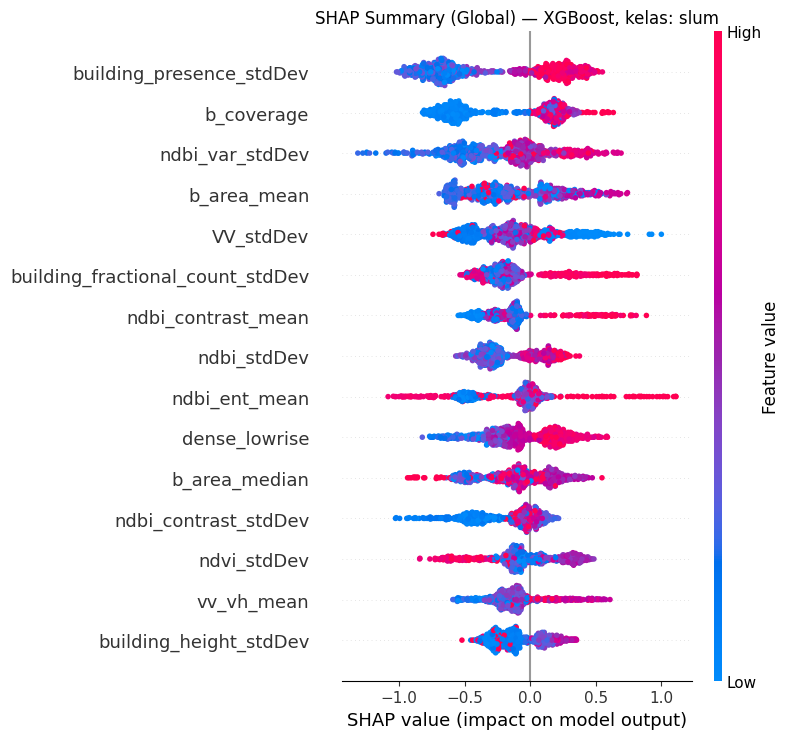

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X, show=False, max_display=15)
plt.title("SHAP Summary (Global) — XGBoost, kelas: slum")
plt.tight_layout()
plt.show()

In [ ]:
global_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_cols
).sort_values(ascending=False)
print("Top 10 fitur paling berkontribusi (rata-rata seluruh dataset):")
global_importance.head(10)

Top 10 fitur paling berkontribusi (rata-rata seluruh dataset):


building_presence_stdDev            0.472913
b_coverage                          0.394727
ndbi_var_stdDev                     0.325346
b_area_mean                         0.310131
VV_stdDev                           0.271294
building_fractional_count_stdDev    0.265864
ndbi_contrast_mean                  0.252270
ndbi_stdDev                         0.245978
ndbi_ent_mean                       0.244780
dense_lowrise                       0.238439
dtype: float32

## 9. SHAP — Local (penjelasan per area, sesuai kebutuhan "Key Factors")

Ini bagian yang menjawab kebutuhan **"faktor tertinggi apa yang membuat
daerah tersebut slum"** — kontribusi fitur untuk SATU area spesifik,
bukan rata-rata seluruh dataset. Inilah yang ditampilkan README sebagai
*Key Factors* pada hasil prediksi tiap lokasi.

Bedanya dengan SHAP Global di atas: Global menjawab "fitur apa yang
penting secara umum untuk model ini", sedangkan Local menjawab "kenapa
AREA INI SPESIFIK diprediksi slum/non-slum" — jawabannya bisa berbeda
untuk setiap kelurahan.

In [ ]:
def explain_one_area(row_index: int, top_n: int = 8) -> pd.DataFrame:
    """Local SHAP untuk satu area: fitur apa yang paling mendorong/menahan
    prediksi slum untuk baris data ini secara spesifik."""
    x_row = X.loc[[row_index]]                          # ambil 1 baris saja, tetap dalam bentuk dataframe
    proba = xgb_final.predict_proba(x_row)[0, 1]         # probabilitas slum untuk baris ini
    sv_row = explainer.shap_values(x_row)                # SHAP value HANYA untuk baris ini (bukan semua data)
    if isinstance(sv_row, list):
        sv_row = sv_row[-1]
    sv_row = sv_row[0]  # ambil baris pertama (dan satu-satunya) dari hasil array SHAP

    explanation = pd.DataFrame({
        "feature": feature_cols,
        "value": x_row.iloc[0].values,      # nilai asli fitur untuk area ini
        "shap_value": sv_row,                # seberapa besar & ke arah mana fitur ini mendorong prediksi
    })
    explanation["abs_shap"] = explanation["shap_value"].abs()
    # Urutkan dari pengaruh paling besar (tidak peduli positif/negatif), ambil top_n teratas
    explanation = explanation.sort_values("abs_shap", ascending=False).head(top_n)
    # shap_value positif -> fitur ini mendorong prediksi ke arah SLUM
    # shap_value negatif -> fitur ini menahan/mendorong ke arah NON-SLUM
    explanation["arah"] = np.where(explanation["shap_value"] > 0,
                                    "-> mendorong ke SLUM", "-> menahan ke NON-SLUM")

    info = df.loc[row_index, ["unit_id", "city", TARGET_COL]]
    print(f"Area: {info['unit_id']} ({info['city']}) | label asli: "
          f"{'SLUM' if info[TARGET_COL] == 1 else 'NON-SLUM'} | "
          f"probabilitas model: {proba:.3f} | threshold: {best_threshold_split:.3f} | "
          f"prediksi: {'SLUM' if proba >= best_threshold_split else 'NON-SLUM'}")
    return explanation[["feature", "value", "shap_value", "arah"]]

In [ ]:
# Contoh 1 — sebuah area yang BENAR-BENAR slum, lihat fitur apa yang paling berperan
sample_slum_idx = df[df[TARGET_COL] == 1].index[0]
explain_one_area(sample_slum_idx)

Area: ambon_0011 (ambon) | label asli: SLUM | probabilitas model: 0.945 | threshold: 0.040 | prediksi: SLUM


,feature,value,shap_value,arah
11,ndbi_ent_mean,4.021775,0.889997,-> mendorong ke SLUM
22,building_fractional_count_stdDev,0.001293,0.664537,-> mendorong ke SLUM
10,ndbi_contrast_stdDev,7.950186,-0.579721,-> menahan ke NON-SLUM
14,ndbi_var_stdDev,15.921677,0.459060,-> mendorong ke SLUM
26,building_presence_stdDev,0.257737,0.426815,-> mendorong ke SLUM
36,small_building_dominance,0.798343,-0.323923,-> menahan ke NON-SLUM
2,ndvi_stdDev,0.222587,-0.248616,-> menahan ke NON-SLUM
29,b_area_mean,89.929097,-0.246624,-> menahan ke NON-SLUM


In [ ]:
# Contoh 2 — sebuah area non-slum, sebagai pembanding
sample_nonslum_idx = df[df[TARGET_COL] == 0].index[0]
explain_one_area(sample_nonslum_idx)

Area: ambon_0010 (ambon) | label asli: NON-SLUM | probabilitas model: 0.323 | threshold: 0.040 | prediksi: SLUM


,feature,value,shap_value,arah
11,ndbi_ent_mean,3.895083,-0.651288,-> menahan ke NON-SLUM
22,building_fractional_count_stdDev,0.001282,0.643384,-> mendorong ke SLUM
26,building_presence_stdDev,0.271335,0.468411,-> mendorong ke SLUM
2,ndvi_stdDev,0.269449,-0.426904,-> menahan ke NON-SLUM
29,b_area_mean,89.472551,-0.339923,-> menahan ke NON-SLUM
19,vv_vh_mean,6.904308,-0.277800,-> menahan ke NON-SLUM
35,texture_to_built_ratio,274.240863,-0.273471,-> menahan ke NON-SLUM
6,bsi_stdDev,0.176690,0.272741,-> mendorong ke SLUM


Pola yang diharapkan: pada area slum, fitur seperti `building_presence_stdDev`,
`b_coverage`, atau fitur tekstur (`ndbi_contrast`, `ndbi_var`) biasanya
muncul dengan `shap_value` positif besar (mendorong ke SLUM), sedangkan
`ndvi_mean` yang tinggi biasanya menahan ke arah NON-SLUM. Kalau pola ini
konsisten dengan literatur (lihat referensi di Bagian 0), itu sinyal baik
bahwa model belajar sesuatu yang masuk akal, bukan kebetulan statistik.

## 10. Export artefak untuk `model_service.py`

Dua file yang dihasilkan:
- **`slum_xgb_pipeline.joblib`** — model XGBoost terlatih (siap di-load
  ulang dengan `joblib.load()`, tanpa perlu training ulang).
- **`model_metadata.json`** — threshold, daftar & urutan nama fitur, dan
  metrik validasi. Tanpa file ini, model `.joblib` hanya berisi
  angka-angka tanpa konteks: tidak ada cara mengetahui threshold mana
  yang harus dipakai atau fitur apa yang diharapkan model.

In [ ]:
joblib.dump(xgb_final, MODEL_PATH)  # serialisasi model terlatih ke file .joblib
print(f"Model disimpan -> {MODEL_PATH}")

metadata = {
    "model_file": MODEL_PATH.name,
    "model_type": "XGBClassifier",
    "threshold": round(float(best_threshold_split), 4),  # threshold hasil tuning Bagian 5, BUKAN 0.5 default
    "threshold_selection_method": f"max precision subject to recall >= {TARGET_RECALL} (random stratified split)",
    "feature_names": feature_cols,    # urutan & nama 41 kolom yang model_service.py wajib susun persis seperti ini
    "n_features": len(feature_cols),
    "target_column": TARGET_COL,
    "cities": sorted(df[CITY_COL].unique().tolist()),
    "n_training_rows": int(len(df)),
    "class_balance": {
        "slum": int(y.sum()),
        "non_slum": int((y == 0).sum()),
        "pct_slum": round(float(y.mean() * 100), 2),
    },
    "validation_metrics": {
        # Performa pada random split, pakai threshold yang sudah di-tuning
        "random_split": {
            "recall": round(float(recall_score(y_test, y_pred_tuned, zero_division=0)), 4),
            "precision": round(float(precision_score(y_test, y_pred_tuned, zero_division=0)), 4),
            "f1": round(float(f1_score(y_test, y_pred_tuned, zero_division=0)), 4),
            "roc_auc": round(float(roc_auc_score(y_test, y_proba_split)), 4),
        },
        # Performa rata-rata LOCO, pakai threshold yang sama (lebih jujur/realistis dari random_split di atas)
        "loco_at_threshold": {
            "recall_mean": round(float(loco_at_threshold["recall"].mean()), 4),
            "precision_mean": round(float(loco_at_threshold["precision"].mean()), 4),
            "f1_mean": round(float(loco_at_threshold["f1"].mean()), 4),
        },
        # Untuk pembanding: performa LOCO kalau threshold TIDAK di-tuning (masih 0.5 default)
        "loco_default_threshold_0_5": {
            "recall_mean": round(float(loco_summary.loc["mean", "recall"]), 4),
            "precision_mean": round(float(loco_summary.loc["mean", "precision"]), 4),
            "roc_auc_mean": round(float(loco_summary.loc["mean", "roc_auc"]), 4),
        },
    },
    "top_global_features": global_importance.head(10).round(4).to_dict(),
    "trained_on": str(date.today()),
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)  # indent=2 supaya file mudah dibaca manusia kalau dibuka langsung

print(f"Metadata disimpan -> {METADATA_PATH}\n")
print(json.dumps(metadata, indent=2)[:1500], "\n...")

Model disimpan -> models\slum_xgb_pipeline.joblib
Metadata disimpan -> models\model_metadata.json

{
  "model_file": "slum_xgb_pipeline.joblib",
  "model_type": "XGBClassifier",
  "threshold": 0.04,
  "threshold_selection_method": "max precision subject to recall >= 0.8 (random stratified split)",
  "feature_names": [
    "area_m2",
    "ndvi_mean",
    "ndvi_stdDev",
    "ndbi_mean",
    "ndbi_stdDev",
    "bsi_mean",
    "bsi_stdDev",
    "brightness_mean",
    "brightness_stdDev",
    "ndbi_contrast_mean",
    "ndbi_contrast_stdDev",
    "ndbi_ent_mean",
    "ndbi_ent_stdDev",
    "ndbi_var_mean",
    "ndbi_var_stdDev",
    "VV_mean",
    "VV_stdDev",
    "VH_mean",
    "VH_stdDev",
    "vv_vh_mean",
    "vv_vh_stdDev",
    "building_fractional_count_mean",
    "building_fractional_count_stdDev",
    "building_height_mean",
    "building_height_stdDev",
    "building_presence_mean",
    "building_presence_stdDev",
    "b_count",
    "b_area_sum",
    "b_area_mean",
    "b_area_std",

## 11. Ringkasan

- Model: **XGBoost** (sesuai README, tidak ada perbandingan dengan
  Random Forest pada notebook ini).
- Threshold final: ditentukan otomatis di Bagian 5 (target recall ≥ 0.80
  pada random split, lalu divalidasi ulang pada skema LOCO).
- LOCO tetap dilaporkan sebagai metrik evaluasi utama (Bagian 3 & 5.1);
  random split hanya sebagai sanity check, bukan metrik akhir.
- SHAP disediakan dalam dua bentuk: **global** (Bagian 8 — validasi pola
  model secara umum) dan **local** (Bagian 9 — penjelasan per area,
  inilah yang menjawab "faktor tertinggi apa yang membuat daerah ini
  slum").
- Artefak `slum_xgb_pipeline.joblib` + `model_metadata.json` siap
  dipakai langsung oleh `model_service.py`.

In [ ]:
print("Ringkasan akhir:")
print(f"  Threshold final           : {best_threshold_split:.4f}")
print(f"  Recall (random split)     : {metadata['validation_metrics']['random_split']['recall']}")
print(f"  Precision (random split)  : {metadata['validation_metrics']['random_split']['precision']}")
print(f"  Recall rata-rata (LOCO)   : {metadata['validation_metrics']['loco_at_threshold']['recall_mean']}")
print(f"  Precision rata-rata (LOCO): {metadata['validation_metrics']['loco_at_threshold']['precision_mean']}")
print(f"\nTop 5 fitur paling berkontribusi (global SHAP):")
print(global_importance.head(5).round(4))

Ringkasan akhir:
  Threshold final           : 0.0400
  Recall (random split)     : 0.8261
  Precision (random split)  : 0.2468
  Recall rata-rata (LOCO)   : 0.783
  Precision rata-rata (LOCO): 0.4276

Top 5 fitur paling berkontribusi (global SHAP):
building_presence_stdDev    0.4729
b_coverage                  0.3947
ndbi_var_stdDev             0.3253
b_area_mean                 0.3101
VV_stdDev                   0.2713
dtype: float32
